<a href="https://colab.research.google.com/github/lxndrkrln/laba_ML/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Данные с каггла https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# Разведочный анализ, заполнение пропусков, преобразование категориальных признаков

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv("TCC.csv")
data.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [21]:
# Заменяем пробелы на NaN и преобразуем в число
data['TotalCharges'] = data['TotalCharges'].replace(' ', np.nan)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
# Заполняем пропуски средним
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].mean())

In [22]:
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [23]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Как видно из результатов, пропущенные значения в датасете отсутствуют.  
Поэтому операции заполнения пропусков не требуются и могут быть пропущены.

In [24]:
# Список категориальных признаков для кодирования
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                    'PaperlessBilling', 'PaymentMethod']

# One-Hot Encoding категориальных признаков
data_encoded = pd.get_dummies(
    data,
    columns=categorical_cols,
    prefix=categorical_cols
)
# Удаление ненужных столбцов
data_encoded = data_encoded.drop(columns=['customerID'])
# Преобразуем целевой признак
data_encoded['Churn'] = (data_encoded['Churn'] == 'Yes').astype(int)
data_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,0,False,True,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,0,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,1,True,False,True,False,True,...,False,True,False,False,False,True,False,False,True,False


<Axes: >

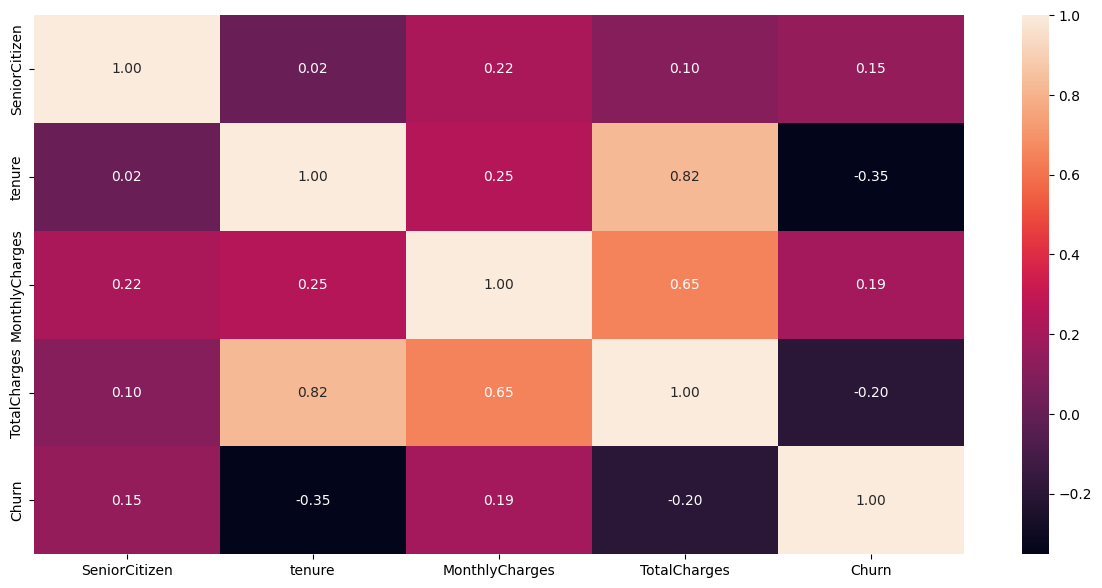

In [25]:
fig, ax = plt.subplots(figsize=(15,7))
numeric_cols = data_encoded.select_dtypes(include=[np.number]).columns
sns.heatmap(data_encoded[numeric_cols].corr(method='pearson'), ax=ax, annot=True, fmt='.2f')

In [26]:
X = data_encoded.drop(columns=['Churn'])
y = data_encoded['Churn']

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Логистическая регрессия

In [29]:
log_reg_model = LogisticRegression(max_iter=5000)
log_reg_model.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg_model.predict(X_test_scaled)
y_proba_log_reg = log_reg_model.predict_proba(X_test_scaled)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_log_reg):.4f}")

Accuracy: 0.8204
ROC-AUC: 0.8620


# Метод опорных векторов (SVM)

In [30]:
SVC_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)
SVC_model.fit(X_train_scaled, y_train)
y_pred_SVC = SVC_model.predict(X_test_scaled)
y_proba_SVC = SVC_model.predict_proba(X_test_scaled)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_SVC):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_SVC):.4f}")

Accuracy: 0.8119
ROC-AUC: 0.8227


# Дерево решений

In [31]:
tree_model = DecisionTreeClassifier(
    max_depth=7,
    random_state=42
)
tree_model.fit(X_train_scaled, y_train)
y_pred_tree = tree_model.predict(X_test_scaled)
y_proba_tree = tree_model.predict_proba(X_test_scaled)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_tree):.4f}")

Accuracy: 0.7949
ROC-AUC: 0.8321


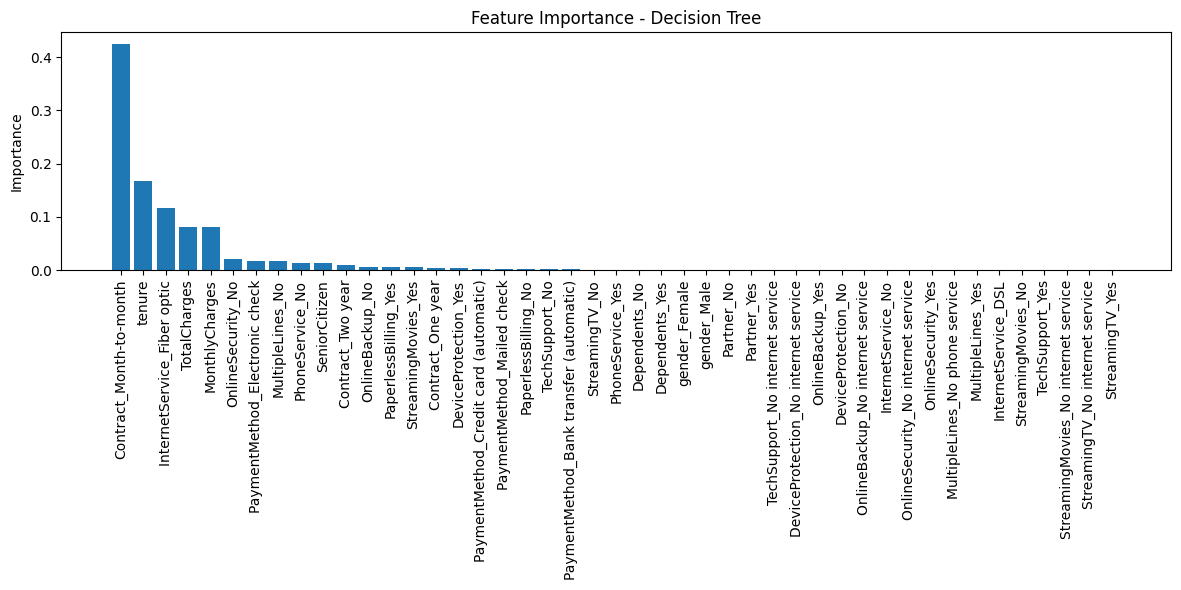

In [32]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
plt.figure(figsize=(12, 6))
plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xticks(rotation=90)
plt.title("Feature Importance - Decision Tree")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

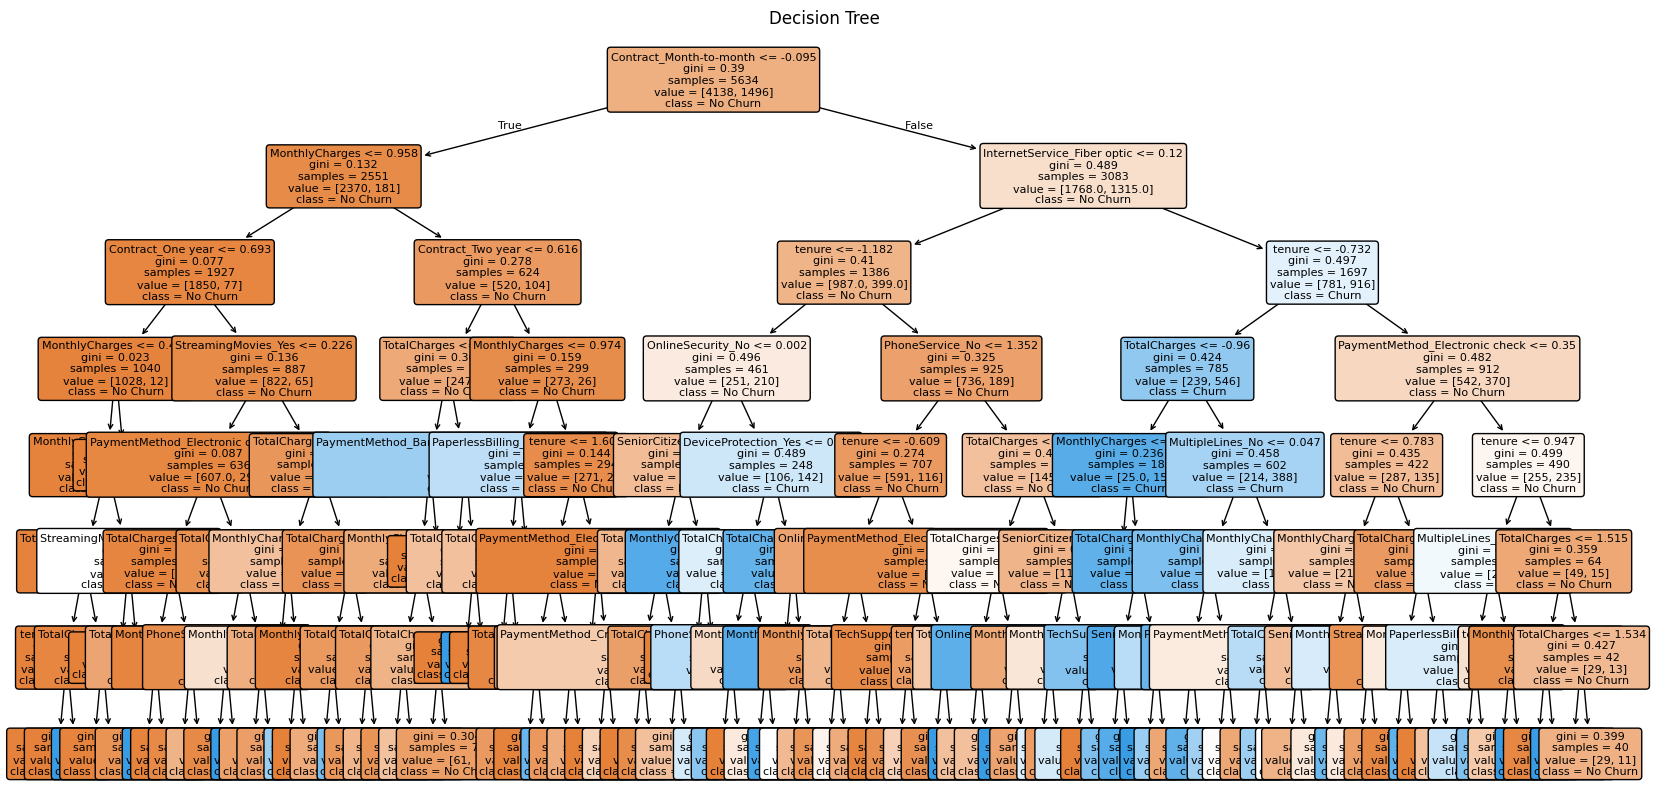

In [33]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree")
plt.show()

In [34]:
tree_rules = export_text(
    tree_model,
    feature_names=list(X.columns)
)

print(tree_rules)

|--- Contract_Month-to-month <= -0.09
|   |--- MonthlyCharges <= 0.96
|   |   |--- Contract_One year <= 0.69
|   |   |   |--- MonthlyCharges <= 0.49
|   |   |   |   |--- MonthlyCharges <= 0.49
|   |   |   |   |   |--- TotalCharges <= 0.97
|   |   |   |   |   |   |--- tenure <= 1.11
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- tenure >  1.11
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- TotalCharges >  0.97
|   |   |   |   |   |   |--- TotalCharges <= 0.97
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- TotalCharges >  0.97
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- MonthlyCharges >  0.49
|   |   |   |   |   |--- StreamingMovies_Yes <= 0.23
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- StreamingMovies_Yes >  0.23
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- MonthlyCharges >  0.49
|   |   |   |   |--- class: 0
|   |   |--- Contract_One year >  0.69
|   |   |   |--- Streami

# Сравнение и выводы

                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.820440  0.861978
1                  SVC  0.811923  0.822726
2        Decision Tree  0.794890  0.832099


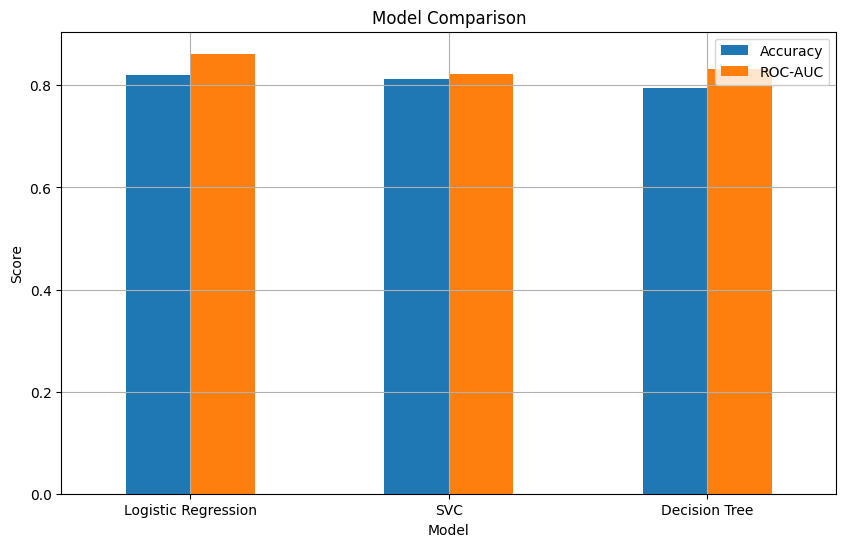

In [35]:
results = []

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_log_reg),
    'ROC-AUC': roc_auc_score(y_test, y_proba_log_reg)
})

results.append({
    'Model': 'SVC',
    'Accuracy': accuracy_score(y_test, y_pred_SVC),
    'ROC-AUC': roc_auc_score(y_test, y_proba_SVC)
})

results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_tree),
    'ROC-AUC': roc_auc_score(y_test, y_proba_tree)
})

results_df = pd.DataFrame(results)
print(results_df)

results_df.set_index('Model')[['Accuracy', 'ROC-AUC']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

## Вывод

Лучшие результаты по обеим метрикам (Accuracy и ROC-AUC) показала **логистическая регрессия**.  
Метод опорных векторов дал близкие, но чуть более низкие значения.  
Дерево решений уступило обеим моделям, что характерно для данных со сложными нелинейными зависимостями, но при этом оно остаётся полезным для интерпретации.